# Cluster and Sample Unlabeled Acoustic Embeddings (Silhouette)

This notebook:
1. Loads the 1536-dim Perch embeddings
2. Reduces to **3D** with **UMAP** (full) and **t-SNE** (subset)
3. Finds best **k** with **Silhouette Score**
4. Clusters with K-means using best k
5. Samples audio files per cluster and saves outputs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from os import environ

import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tqdm import tqdm

import shutil

## 1. Load Embeddings and Manifest

In [2]:
env_dir = environ.get("POSIDONIA_DATASET_DIR")
DATASET_DIR = Path(env_dir) if env_dir else Path("D:/Posidonia Soundscapes/Fondeo 1_Formentera Ille Espardell/Embeddings_2/dataset")

EMBEDDINGS_PATH = DATASET_DIR / "npy_files" / "unlabeled_embeddings.npy"
MANIFEST_PATH = DATASET_DIR / "unlabeled_manifest.csv"

if not EMBEDDINGS_PATH.exists() or not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Missing files:\n"
        f"  embeddings: {EMBEDDINGS_PATH}\n"
        f"  manifest:   {MANIFEST_PATH}\n"
        f"Set POSIDONIA_DATASET_DIR to the correct dataset folder."
    )

embeddings = np.load(str(EMBEDDINGS_PATH))
manifest_df = pd.read_csv(str(MANIFEST_PATH))

print(f"Loaded {embeddings.shape[0]} embeddings of dimension {embeddings.shape[1]}")
print(f"Manifest rows: {len(manifest_df)}")
manifest_df.head()

Loaded 392400 embeddings of dimension 1536
Manifest rows: 392400


,original_audio,embedding_path,segment_path,audio_path,file_name,embedding_dim
0,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,NaN,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,channelA_2025-05-16_14-00-03.wav,1536
1,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,NaN,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,channelA_2025-05-16_14-00-08.wav,1536
2,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,NaN,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,channelA_2025-05-16_14-00-13.wav,1536
3,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,NaN,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,channelA_2025-05-16_14-00-18.wav,1536
4,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,NaN,/mnt/d/Posidonia Soundscapes/Fondeo 1_Formente...,channelA_2025-05-16_14-00-23.wav,1536


## 2. Dimensionality Reduction: UMAP and t-SNE to 3D

In [3]:
output_dir = EMBEDDINGS_PATH.parent
umap_tsne_output_dir = output_dir / "umap_and_tsne"
umap_tsne_output_dir.mkdir(parents=True, exist_ok=True)

umap_file = umap_tsne_output_dir / "umap_embeddings.npy"
tsne_file = umap_tsne_output_dir / "tsne_subset_embeddings.npy"
tsne_idx_file = umap_tsne_output_dir / "tsne_subset_indices.npy"

if umap_file.exists() and tsne_file.exists() and tsne_idx_file.exists():
    print("Loading pre-computed UMAP and t-SNE embeddings...")
    umap_results = np.load(str(umap_file))
    tsne_results = np.load(str(tsne_file))
    tsne_idx = np.load(str(tsne_idx_file))
else:
    print("Pre-reducing to 256D with PCA to avoid memory crashes...")
    embeddings_fp32 = embeddings.astype(np.float32, copy=False)
    embeddings_pca_256 = PCA(n_components=256, random_state=42).fit_transform(embeddings_fp32)

    print("Running UMAP on 256D embeddings...")
    umap_results = umap.UMAP(
        n_components=3,
        random_state=42,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        low_memory=True
    ).fit_transform(embeddings_pca_256)

    print("Running t-SNE on subset for visualization...")
    TSNE_VIS_LIMIT = 50000
    rng = np.random.default_rng(42)
    tsne_idx = rng.choice(embeddings.shape[0], size=min(TSNE_VIS_LIMIT, embeddings.shape[0]), replace=False)
    tsne_results = TSNE(n_components=3, random_state=42, perplexity=30).fit_transform(embeddings_pca_256[tsne_idx])

    np.save(str(umap_file), umap_results)
    np.save(str(tsne_file), tsne_results)
    np.save(str(tsne_idx_file), tsne_idx)

manifest_df['umap_x'] = umap_results[:, 0]
manifest_df['umap_y'] = umap_results[:, 1]
manifest_df['umap_z'] = umap_results[:, 2]

manifest_df['tsne_x'] = np.nan
manifest_df['tsne_y'] = np.nan
manifest_df['tsne_z'] = np.nan
manifest_df.loc[tsne_idx, 'tsne_x'] = tsne_results[:, 0]
manifest_df.loc[tsne_idx, 'tsne_y'] = tsne_results[:, 1]
manifest_df.loc[tsne_idx, 'tsne_z'] = tsne_results[:, 2]

print("UMAP and t-SNE embeddings ready.")

Loading pre-computed UMAP and t-SNE embeddings...
UMAP and t-SNE embeddings ready.


## 3. Find Optimal k with Silhouette Score

In [4]:
K_VALUES = list(range(5, 81, 5))
SILHOUETTE_MAX_POINTS = 20000

def silhouette_k_search(data, k_values, max_points=20000, seed=42):
    rng = np.random.default_rng(seed)

    if len(data) > max_points:
        sample_idx = rng.choice(len(data), size=max_points, replace=False)
        data_eval = data[sample_idx]
    else:
        sample_idx = np.arange(len(data))
        data_eval = data

    scores = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(data_eval)
        score = silhouette_score(data_eval, labels)
        scores.append(score)
        print(f"k={k:>2} | silhouette={score:.4f}")

    scores = np.array(scores)
    best_idx = int(np.argmax(scores))
    best_k = k_values[best_idx]
    return best_k, scores, sample_idx

print("Searching optimal k for UMAP embeddings...")
best_k_umap, umap_scores, _ = silhouette_k_search(umap_results, K_VALUES, SILHOUETTE_MAX_POINTS)
print(f"Best UMAP k: {best_k_umap}")

print("\nSearching optimal k for t-SNE subset embeddings...")
best_k_tsne, tsne_scores, _ = silhouette_k_search(tsne_results, K_VALUES, SILHOUETTE_MAX_POINTS)
print(f"Best t-SNE k: {best_k_tsne}")

Searching optimal k for UMAP embeddings...


c:\Users\USER\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\USER\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\USER\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\USER\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

k= 5 | silhouette=0.4596
k=10 | silhouette=0.3673
k=15 | silhouette=0.3664
k=20 | silhouette=0.3454
k=25 | silhouette=0.3238
k=30 | silhouette=0.3092
k=35 | silhouette=0.3017
k=40 | silhouette=0.2917
k=45 | silhouette=0.2878
k=50 | silhouette=0.2871
k=55 | silhouette=0.2825
k=60 | silhouette=0.2748
k=65 | silhouette=0.2761
k=70 | silhouette=0.2829
k=75 | silhouette=0.2795
k=80 | silhouette=0.2752
Best UMAP k: 5

Searching optimal k for t-SNE subset embeddings...
k= 5 | silhouette=0.2995
k=10 | silhouette=0.2761
k=15 | silhouette=0.2647
k=20 | silhouette=0.2652
k=25 | silhouette=0.2627
k=30 | silhouette=0.2587
k=35 | silhouette=0.2600
k=40 | silhouette=0.2514
k=45 | silhouette=0.2518
k=50 | silhouette=0.2535
k=55 | silhouette=0.2515
k=60 | silhouette=0.2495
k=65 | silhouette=0.2460
k=70 | silhouette=0.2518
k=75 | silhouette=0.2516
k=80 | silhouette=0.2487
Best t-SNE k: 5


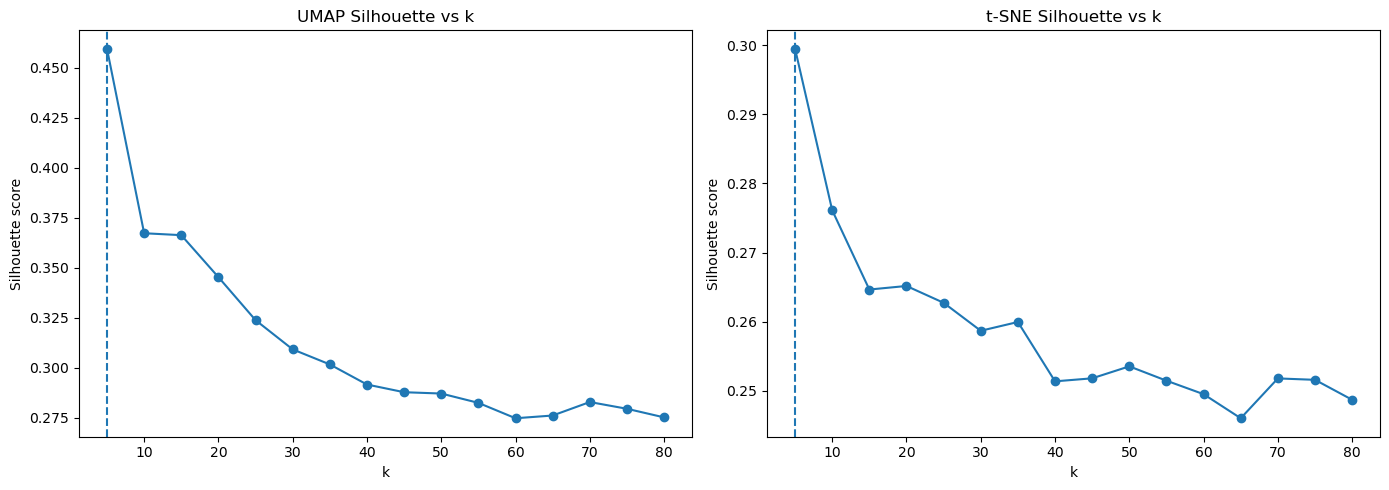

Saved: D:\Posidonia Soundscapes\Fondeo 1_Formentera Ille Espardell\Embeddings_2\dataset\npy_files\umap_and_tsne\silhouette_umap_scores.csv
Saved: D:\Posidonia Soundscapes\Fondeo 1_Formentera Ille Espardell\Embeddings_2\dataset\npy_files\umap_and_tsne\silhouette_tsne_scores.csv
Saved: D:\Posidonia Soundscapes\Fondeo 1_Formentera Ille Espardell\Embeddings_2\dataset\npy_files\umap_and_tsne\silhouette_best_k.txt


In [5]:
silhouette_umap_df = pd.DataFrame({'k': K_VALUES, 'silhouette': umap_scores})
silhouette_tsne_df = pd.DataFrame({'k': K_VALUES, 'silhouette': tsne_scores})

silhouette_umap_csv = umap_tsne_output_dir / 'silhouette_umap_scores.csv'
silhouette_tsne_csv = umap_tsne_output_dir / 'silhouette_tsne_scores.csv'
best_k_txt = umap_tsne_output_dir / 'silhouette_best_k.txt'

silhouette_umap_df.to_csv(silhouette_umap_csv, index=False)
silhouette_tsne_df.to_csv(silhouette_tsne_csv, index=False)
with open(best_k_txt, 'w', encoding='utf-8') as f:
    f.write(f"best_k_umap={best_k_umap}\n")
    f.write(f"best_k_tsne={best_k_tsne}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_VALUES, umap_scores, marker='o')
axes[0].axvline(best_k_umap, linestyle='--')
axes[0].set_title('UMAP Silhouette vs k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette score')

axes[1].plot(K_VALUES, tsne_scores, marker='o')
axes[1].axvline(best_k_tsne, linestyle='--')
axes[1].set_title('t-SNE Silhouette vs k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

print(f"Saved: {silhouette_umap_csv}")
print(f"Saved: {silhouette_tsne_csv}")
print(f"Saved: {best_k_txt}")

## 4. K-means Clustering with Best k

In [6]:
umap_labels_file = umap_tsne_output_dir / f"umap_kmeans_labels_k{best_k_umap}.npy"
tsne_labels_file = umap_tsne_output_dir / f"tsne_subset_kmeans_labels_k{best_k_tsne}.npy"

kmeans_umap = KMeans(n_clusters=best_k_umap, random_state=42, n_init=10)
umap_labels = kmeans_umap.fit_predict(umap_results)
centroids_umap = kmeans_umap.cluster_centers_

kmeans_tsne = KMeans(n_clusters=best_k_tsne, random_state=42, n_init=10)
tsne_labels = kmeans_tsne.fit_predict(tsne_results)
centroids_tsne = kmeans_tsne.cluster_centers_

np.save(str(umap_labels_file), umap_labels)
np.save(str(tsne_labels_file), tsne_labels)

manifest_df['umap_cluster'] = umap_labels
manifest_df['tsne_cluster'] = np.nan
manifest_df.loc[tsne_idx, 'tsne_cluster'] = tsne_labels

print(f"UMAP clusters (k={best_k_umap}):")
print(pd.Series(umap_labels).value_counts().sort_index())
print(f"\nt-SNE clusters (k={best_k_tsne}):")
print(pd.Series(tsne_labels).value_counts().sort_index())

UMAP clusters (k=5):
0    123864
1    112391
2     35722
3     64562
4     55861
Name: count, dtype: int64

t-SNE clusters (k=5):
0     9722
1     9330
2     9057
3    11128
4    10763
Name: count, dtype: int64


## 5. Sample Strategy: 20 nearest + 20 farthest + 60 random

In [7]:
def sample_cluster(cluster_indices, cluster_embeddings, centroid, n_nearest=20, n_farthest=20, n_random=60):
    dists = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    order = np.argsort(dists)

    nearest_idx = cluster_indices[order[:min(n_nearest, len(order))]]
    farthest_idx = cluster_indices[order[-min(n_farthest, len(order)):]]

    remaining_idx = np.setdiff1d(cluster_indices, np.unique(np.concatenate([nearest_idx, farthest_idx])))
    n_random_eff = min(n_random, len(remaining_idx))

    if n_random_eff > 0:
        rng = np.random.default_rng(42)
        random_idx = rng.choice(remaining_idx, size=n_random_eff, replace=False)
    else:
        random_idx = np.array([], dtype=int)

    return np.unique(np.concatenate([nearest_idx, farthest_idx, random_idx]))

print('Sampling from UMAP clusters...')
umap_subsample_indices = []
for i in tqdm(range(best_k_umap)):
    cluster_indices = np.where(umap_labels == i)[0]
    cluster_embeddings = umap_results[cluster_indices]
    sampled = sample_cluster(cluster_indices, cluster_embeddings, centroids_umap[i])
    umap_subsample_indices.extend(sampled.tolist())
umap_subsample_indices = np.unique(umap_subsample_indices)

print('Sampling from t-SNE clusters...')
tsne_subsample_indices = []
for i in tqdm(range(best_k_tsne)):
    cluster_indices_subset = np.where(tsne_labels == i)[0]
    cluster_embeddings_subset = tsne_results[cluster_indices_subset]
    sampled_subset = sample_cluster(cluster_indices_subset, cluster_embeddings_subset, centroids_tsne[i])
    sampled_orig = tsne_idx[sampled_subset]
    tsne_subsample_indices.extend(sampled_orig.tolist())
tsne_subsample_indices = np.unique(tsne_subsample_indices)

print(f"Selected {len(umap_subsample_indices)} UMAP samples")
print(f"Selected {len(tsne_subsample_indices)} t-SNE samples")

Sampling from UMAP clusters...


100%|██████████| 5/5 [00:00<00:00, 185.44it/s]


Sampling from t-SNE clusters...


100%|██████████| 5/5 [00:00<00:00, 1384.44it/s]

Selected 500 UMAP samples
Selected 500 t-SNE samples


## 6. Save Results

In [8]:
umap_subsample_df = pd.DataFrame({
    'audio_path': manifest_df.iloc[umap_subsample_indices]['audio_path'].values,
    'embedding_path': manifest_df.iloc[umap_subsample_indices]['embedding_path'].values,
    'reduced_embedding_filepath': str(umap_file),
    'reduced_embeddings_idx': umap_subsample_indices,
    'method': 'umap_silhouette_kmeans',
    'cluster': umap_labels[umap_subsample_indices]
})

tsne_subsample_df = pd.DataFrame({
    'audio_path': manifest_df.iloc[tsne_subsample_indices]['audio_path'].values,
    'embedding_path': manifest_df.iloc[tsne_subsample_indices]['embedding_path'].values,
    'reduced_embedding_filepath': str(tsne_file),
    'reduced_embeddings_idx': tsne_subsample_indices,
    'method': 'tsne_silhouette_kmeans',
    'cluster': manifest_df.iloc[tsne_subsample_indices]['tsne_cluster'].astype(int).values
})

combined_subsample_df = pd.concat([umap_subsample_df, tsne_subsample_df], ignore_index=True)

umap_csv = umap_tsne_output_dir / f"subsample_umap_silhouette_k{best_k_umap}.csv"
tsne_csv = umap_tsne_output_dir / f"subsample_tsne_silhouette_k{best_k_tsne}.csv"
combined_csv = umap_tsne_output_dir / f"subsample_combined_silhouette_k{best_k_umap}_{best_k_tsne}.csv"

umap_subsample_df.to_csv(umap_csv, index=False)
tsne_subsample_df.to_csv(tsne_csv, index=False)
combined_subsample_df.to_csv(combined_csv, index=False)

print(f"Saved UMAP subsample: {umap_csv}")
print(f"Saved t-SNE subsample: {tsne_csv}")
print(f"Saved combined subsample: {combined_csv}")

Saved UMAP subsample: D:\Posidonia Soundscapes\Fondeo 1_Formentera Ille Espardell\Embeddings_2\dataset\npy_files\umap_and_tsne\subsample_umap_silhouette_k5.csv
Saved t-SNE subsample: D:\Posidonia Soundscapes\Fondeo 1_Formentera Ille Espardell\Embeddings_2\dataset\npy_files\umap_and_tsne\subsample_tsne_silhouette_k5.csv
Saved combined subsample: D:\Posidonia Soundscapes\Fondeo 1_Formentera Ille Espardell\Embeddings_2\dataset\npy_files\umap_and_tsne\subsample_combined_silhouette_k5_5.csv


## 7. Copy Audio Samples to Review Folder

In [9]:
def convert_wsl_to_windows_path(wsl_path):
    if isinstance(wsl_path, float):
        return wsl_path
    wsl_path = str(wsl_path).replace('\\', '/')
    if wsl_path.startswith('/mnt/') and len(wsl_path) > 7:
        drive = wsl_path[5].upper()
        rest = wsl_path[7:]
        return f"{drive}:\\{rest}".replace('/', '\\')
    return wsl_path

REVIEW_DIR = Path('D:/Posidonia Soundscapes/Fondeo 1_Formentera Ille Espardell/Embeddings_2/diagnostics/Review_Silhouette')
UMAP_DEST = REVIEW_DIR / 'UMAP'
TSNE_DEST = REVIEW_DIR / 't-SNE'

UMAP_ALL = UMAP_DEST / 'All'
TSNE_ALL = TSNE_DEST / 'All'
UMAP_CLUSTERS = UMAP_DEST / 'Clusters'
TSNE_CLUSTERS = TSNE_DEST / 'Clusters'

for folder in [UMAP_ALL, TSNE_ALL, UMAP_CLUSTERS, TSNE_CLUSTERS]:
    folder.mkdir(parents=True, exist_ok=True)

for i in range(best_k_umap):
    (UMAP_CLUSTERS / str(i + 1)).mkdir(exist_ok=True)
for i in range(best_k_tsne):
    (TSNE_CLUSTERS / str(i + 1)).mkdir(exist_ok=True)

def copy_audio_files(df, all_dest, cluster_dest_root):
    copied, failed = 0, 0
    for _, row in df.iterrows():
        src_path = Path(convert_wsl_to_windows_path(row['audio_path']))
        cluster_dir = cluster_dest_root / str(int(row['cluster']) + 1)

        if not src_path.exists():
            failed += 1
            continue

        dst_all = all_dest / src_path.name
        dst_cluster = cluster_dir / src_path.name

        try:
            shutil.copy2(src_path, dst_all)
            shutil.copy2(src_path, dst_cluster)
            copied += 1
        except Exception:
            failed += 1

    return copied, failed

umap_copied, umap_failed = copy_audio_files(umap_subsample_df, UMAP_ALL, UMAP_CLUSTERS)
tsne_copied, tsne_failed = copy_audio_files(tsne_subsample_df, TSNE_ALL, TSNE_CLUSTERS)

print(f"UMAP copied: {umap_copied}, failed: {umap_failed}")
print(f"t-SNE copied: {tsne_copied}, failed: {tsne_failed}")
print(f"Review folder: {REVIEW_DIR}")

UMAP copied: 500, failed: 0
t-SNE copied: 500, failed: 0
Review folder: D:\Posidonia Soundscapes\Fondeo 1_Formentera Ille Espardell\Embeddings_2\diagnostics\Review_Silhouette
